# Tier 0 · Notebook 3 — Backprop Through the Classic Layers

> **Goal:** hand-derive and hand-code the **backward pass of every layer you'll actually use** — Linear, ReLU/GELU, LayerNorm, BatchNorm, Conv2d — and verify each one against PyTorch to ~1e-9.

**Wait — didn't we just build autograd so we'd never have to do backward by hand again?** Yes. And in practice you'll let autograd do it. But you should still be able to derive each layer's gradient on paper, because:

1. **Interviews ask it.** "Derive the backward pass of BatchNorm" is a genuine ML-interview question (it's famously fiddly). "Why do transformers use LayerNorm instead of BatchNorm?" is another.
2. **Custom kernels need it.** The moment you write a fused CUDA/Triton kernel (FlashAttention, a custom norm), autograd can't help — *you* provide the backward. Every efficiency win at scale is someone hand-writing a backward pass.
3. **Debugging needs it.** When a training run NaNs inside a norm layer, you need to know which term in the gradient blew up.

So this notebook flips the style of Notebooks 1–2. There we built a generic engine; here each **layer is a little module with an explicit `forward` and a hand-written `backward`**, and we treat PyTorch's autograd as the answer key. This is how you truly *own* these layers.

**The layer API we'll use everywhere:**
- `forward(x)` → returns the output, and stashes whatever it needs for the backward.
- `backward(dout)` → given `dout = ∂L/∂output`, returns `dx = ∂L/∂input` and stores parameter gradients (`self.dW`, etc.).

That two-method contract *is* a PyTorch `autograd.Function`. Let's build the test harness first, then the layers.


## 0. The test harness

For every layer we'll do the same thing: make a random input `x` and a random upstream gradient `g` (pretending some scalar loss produced `∂L/∂output = g`), run our manual `backward`, then build the identical op in PyTorch and let *its* autograd compute the truth. If the two agree, our derivation is correct.

Using a *random* `g` (instead of all-ones) matters: it exercises every output element with a distinct weight, so a bug in any single partial derivative shows up.


In [1]:
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline
np.random.seed(0); torch.manual_seed(0)

def compare(name, ours, ref, atol=1e-6):
    ours = np.asarray(ours); ref = np.asarray(ref)
    err = np.abs(ours - ref).max()
    status = "OK ✓" if err < atol else "FAIL ✗"
    print(f"    {name:10s} max|ours - torch| = {err:.2e}   {status}")
    assert err < atol, f"{name}: max|ours - torch| = {err:.2e} exceeds atol={atol:.0e}"
    return err

def as_t(a):
    """numpy -> torch double tensor that tracks gradients."""
    return torch.tensor(a, dtype=torch.float64, requires_grad=True)

print("harness ready — torch", torch.__version__)


harness ready — torch 2.6.0+cu124


## 1. Linear — the warm-up (establishes the pattern)

We derived this in Notebook 2; here we recast it as a manual-backward module so the pattern is crisp. Forward: $Y = XW + b$ with $X:(N, d_\text{in})$, $W:(d_\text{in}, d_\text{out})$, $b:(d_\text{out})$.

Backward, given $\bar Y = \partial L/\partial Y$ (shape $(N, d_\text{out})$) — these are the three matmul-chain-rule results (each gradient has the shape of the thing it's a gradient of):
$$\frac{\partial L}{\partial X} = \bar Y\,W^{\mathsf T}, \qquad \frac{\partial L}{\partial W} = X^{\mathsf T}\bar Y, \qquad \frac{\partial L}{\partial b} = \sum_{\text{rows}} \bar Y.$$
The bias gradient **sums over the batch** because $b$ is broadcast across all $N$ rows — the exact `unbroadcast` lesson from Notebook 2, now showing up as a plain `.sum(axis=0)`.


In [2]:
class Linear:
    def __init__(self, d_in, d_out):
        self.W = np.random.randn(d_in, d_out) * np.sqrt(2.0 / d_in)
        self.b = np.zeros(d_out)

    def forward(self, x):
        self.x = x                      # stash input for backward
        return x @ self.W + self.b

    def backward(self, dout):
        self.dW = self.x.T @ dout       # X^T Ȳ
        self.db = dout.sum(axis=0)      # sum over batch (bias was broadcast)
        return dout @ self.W.T          # Ȳ W^T   -> dx

# --- verify vs PyTorch ---
x = np.random.randn(8, 5); g = np.random.randn(8, 3)   # input and upstream grad
lin = Linear(5, 3)
y = lin.forward(x); dx = lin.backward(g)

xt, Wt, bt = as_t(x), as_t(lin.W), as_t(lin.b)
(( xt @ Wt + bt) * torch.tensor(g)).sum().backward()
print("Linear:")
compare("dx", dx, xt.grad); compare("dW", lin.dW, Wt.grad); compare("db", lin.db, bt.grad)


Linear:
    dx         max|ours - torch| = 2.22e-16   OK ✓
    dW         max|ours - torch| = 8.88e-16   OK ✓
    db         max|ours - torch| = 8.88e-16   OK ✓


8.881784197001252e-16

**What to notice.** All three gradients match PyTorch to ~1e-15 (double precision). The pattern here is the template for *every* layer below: stash what you need in `forward`, and in `backward` turn the incoming `dout` into (a) the input gradient you return and (b) the parameter gradients you store. Keep an eye on `db.shape == (3,)` — the batch dimension is gone, summed away, exactly as broadcasting demands.


## 2. Activations: ReLU and GELU

**ReLU** $= \max(0, x)$ is a gate: its derivative is 1 where the input was positive and 0 elsewhere, so backward just masks `dout`. Trivial but worth stating: the gradient is *killed* wherever the unit was off — this is both ReLU's strength (sparsity) and its weakness ("dead" units that never turn back on).

**GELU** (Gaussian Error Linear Unit) is the smooth activation used in GPT/BERT-style transformers. Instead of a hard 0/1 gate, it weights each input by *how likely it is to be kept*, using the Gaussian CDF. We use the common **tanh approximation**:
$$\text{GELU}(x) = 0.5\,x\,\big(1 + \tanh(u)\big), \qquad u = \sqrt{\tfrac{2}{\pi}}\,\big(x + 0.044715\,x^3\big).$$
Let's derive its backward. Let $c=\sqrt{2/\pi}$, $a=0.044715$, and $t=\tanh(u)$. Product rule on $0.5x(1+t)$:
$$\frac{d\,\text{GELU}}{dx} = 0.5(1 + t) + 0.5\,x\,(1 - t^2)\,\frac{du}{dx}, \qquad \frac{du}{dx} = c\,(1 + 3a x^2).$$
The first term is "let the value through"; the second is the correction from the smooth gate reacting to $x$. Notice it reuses $t$ (the forward's tanh) — same trick as Notebook 1.


In [3]:
class ReLU:
    def forward(self, x):
        self.mask = x > 0
        return np.where(self.mask, x, 0.0)
    def backward(self, dout):
        return dout * self.mask          # pass grad where active, block elsewhere

class GELU:
    c = np.sqrt(2.0 / np.pi); a = 0.044715
    def forward(self, x):
        self.x = x
        self.u = self.c * (x + self.a * x**3)
        self.t = np.tanh(self.u)
        return 0.5 * x * (1.0 + self.t)
    def backward(self, dout):
        x, t = self.x, self.t
        dudx = self.c * (1.0 + 3.0 * self.a * x**2)
        dgelu = 0.5 * (1.0 + t) + 0.5 * x * (1.0 - t**2) * dudx
        return dout * dgelu

# --- verify both vs PyTorch ---
x = np.random.randn(6, 4); g = np.random.randn(6, 4)
r = ReLU(); r.forward(x); dxr = r.backward(g)
xt = as_t(x); (F.relu(xt) * torch.tensor(g)).sum().backward()
print("ReLU:");  compare("dx", dxr, xt.grad)

gl = GELU(); gl.forward(x); dxg = gl.backward(g)
xt = as_t(x); (F.gelu(xt, approximate='tanh') * torch.tensor(g)).sum().backward()
print("GELU:");  compare("dx", dxg, xt.grad)


ReLU:
    dx         max|ours - torch| = 0.00e+00   OK ✓
GELU:
    dx         max|ours - torch| = 0.00e+00   OK ✓


0.0

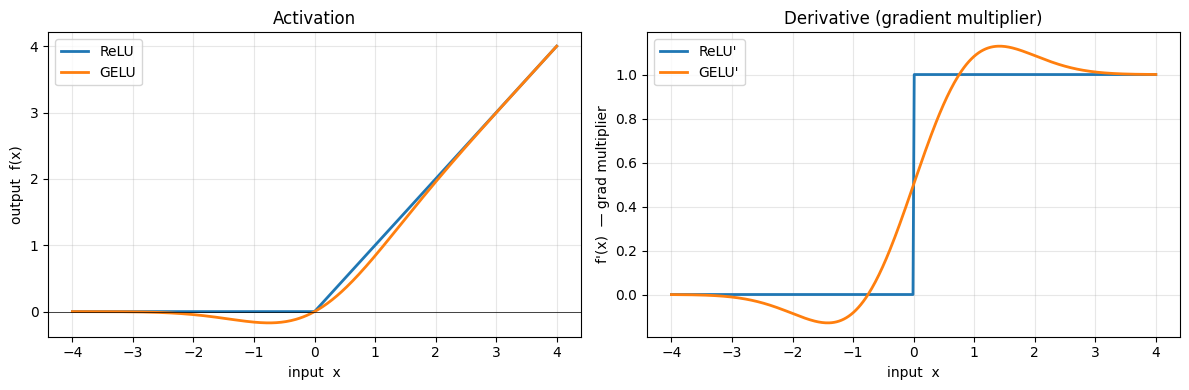

In [4]:
xs = np.linspace(-4, 4, 400)
relu_y  = np.maximum(0, xs)
gelu = GELU(); gelu_y = gelu.forward(xs.copy())
gelu_dy = gelu.backward(np.ones_like(xs))     # derivative via our backward with dout=1
relu_dy = (xs > 0).astype(float)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(xs, relu_y, label="ReLU", lw=2)
ax[0].plot(xs, gelu_y, label="GELU", lw=2)
ax[0].set_title("Activation"); ax[0].legend(); ax[0].grid(alpha=0.3); ax[0].axhline(0, color='k', lw=0.5)
ax[0].set_xlabel("input  x"); ax[0].set_ylabel("output  f(x)")
ax[1].plot(xs, relu_dy, label="ReLU'", lw=2)
ax[1].plot(xs, gelu_dy, label="GELU'", lw=2)
ax[1].set_title("Derivative (gradient multiplier)"); ax[1].legend(); ax[1].grid(alpha=0.3)
ax[1].set_xlabel("input  x"); ax[1].set_ylabel("f'(x)  — grad multiplier")
plt.tight_layout(); plt.show()


**What to notice.** ReLU's derivative is a hard step: exactly 0 for all negative inputs (gradient completely blocked) and exactly 1 for positive. GELU's derivative is a **smooth curve** that stays slightly negative-friendly: for small negative $x$ it's still nonzero, so those units keep receiving a gradient and can recover — no hard "dead ReLU" cliff. It even dips **above 1 and below 0** near the origin, giving the optimizer a richer, smoother signal. That smoothness is a big reason transformers prefer GELU. This plot literally *is* the "gradient multiplier" each activation applies during backprop.


## 3. LayerNorm — normalize each example across its features

**Intuition.** As signals pass through many layers, their scale drifts — some activations balloon, others shrink — which makes optimization hard. Normalization layers re-center and re-scale activations to a clean distribution (mean 0, variance 1), then let the network *learn* a preferred scale/shift via parameters $\gamma, \beta$. **LayerNorm** does this **per example, across the feature dimension** — every token/row is normalized using its own features, independently of the rest of the batch. (That batch-independence is why it dominates in transformers; more below.)

**Forward** for input $x:(N, D)$, normalizing over the $D$ features:
$$\mu = \tfrac1D\sum_i x_i,\quad \sigma^2 = \tfrac1D\sum_i (x_i-\mu)^2,\quad \hat x = \frac{x-\mu}{\sqrt{\sigma^2+\varepsilon}},\quad y = \gamma\hat x + \beta.$$

**Backward.** The tricky part is $\partial L/\partial x$, because $x$ affects $y$ through **three routes**: directly via $\hat x$, and indirectly through $\mu$ and $\sigma^2$ (which every element helped compute). Carrying all three through the chain rule and simplifying gives the compact result (reducing over the $D$ axis):
$$\frac{\partial L}{\partial \hat x} = \bar y\,\gamma, \qquad
\frac{\partial L}{\partial x} = \frac{1}{\sqrt{\sigma^2+\varepsilon}}\left(\frac{\partial L}{\partial \hat x} - \underbrace{\overline{\tfrac{\partial L}{\partial \hat x}}}_{\text{mean term}} - \hat x\;\underbrace{\overline{\tfrac{\partial L}{\partial \hat x}\,\hat x}}_{\text{var term}}\right),$$
where the overbar means "mean over the $D$ features." The parameter grads are the easy ones: $\partial L/\partial\gamma = \sum_N \bar y\,\hat x$ and $\partial L/\partial\beta = \sum_N \bar y$ (summed over the batch, since $\gamma,\beta$ are shared across examples).

**Read the three terms as a sentence:** "take the direct gradient, then subtract off its mean (you can't change the average — normalization removed that degree of freedom) and subtract the part correlated with $\hat x$ (you can't change the variance either)." Normalization *removes* two degrees of freedom, and the backward pass is precisely the projection that respects that.


In [5]:
class LayerNorm:
    def __init__(self, D, eps=1e-5):
        self.gamma = np.ones(D); self.beta = np.zeros(D); self.eps = eps
    def forward(self, x):
        self.mu  = x.mean(axis=1, keepdims=True)
        self.var = x.var(axis=1, keepdims=True)
        self.std = np.sqrt(self.var + self.eps)
        self.xhat = (x - self.mu) / self.std
        return self.gamma * self.xhat + self.beta
    def backward(self, dout):
        D = dout.shape[1]
        self.dgamma = (dout * self.xhat).sum(axis=0)
        self.dbeta  = dout.sum(axis=0)
        dxhat = dout * self.gamma
        # the three-route result, reducing over the feature axis (axis=1)
        dx = (dxhat
              - dxhat.mean(axis=1, keepdims=True)
              - self.xhat * (dxhat * self.xhat).mean(axis=1, keepdims=True)) / self.std
        return dx

# --- verify vs PyTorch ---
x = np.random.randn(8, 16); g = np.random.randn(8, 16)
ln = LayerNorm(16); ln.gamma = np.random.randn(16); ln.beta = np.random.randn(16)
ln.forward(x); dx = ln.backward(g)

xt, gam, bet = as_t(x), as_t(ln.gamma), as_t(ln.beta)
(F.layer_norm(xt, (16,), weight=gam, bias=bet, eps=1e-5) * torch.tensor(g)).sum().backward()
print("LayerNorm:")
compare("dx", dx, xt.grad); compare("dgamma", ln.dgamma, gam.grad); compare("dbeta", ln.dbeta, bet.grad)


LayerNorm:
    dx         max|ours - torch| = 6.66e-16   OK ✓
    dgamma     max|ours - torch| = 8.88e-16   OK ✓
    dbeta      max|ours - torch| = 0.00e+00   OK ✓


0.0

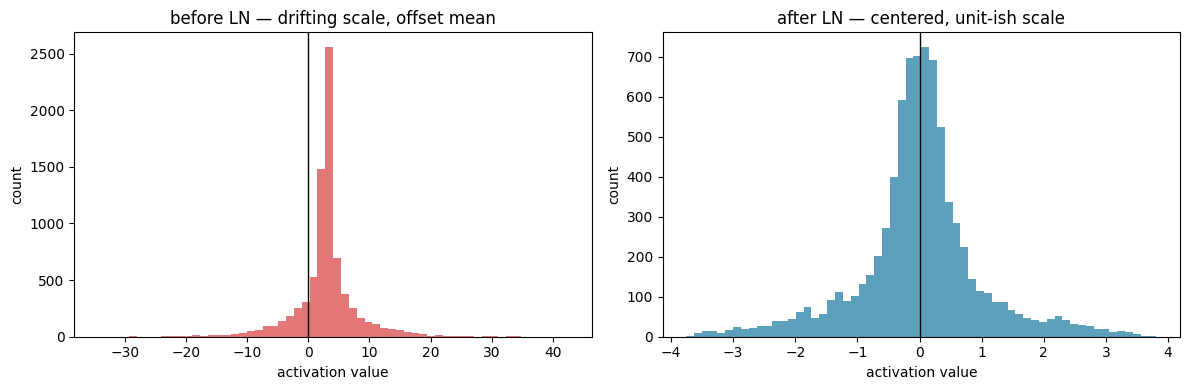

before: mean +2.94, std 5.17   |   after: mean -0.00, std 1.00


In [6]:
# visualize what LN does to a batch of wildly-scaled features
raw = np.random.randn(500, 16) * np.array([0.2, 5, 1, 12, 0.5, 3, 8, 1,
                                           0.3, 6, 2, 9, 0.7, 4, 7, 1.5]) + 3
normed = LayerNorm(16).forward(raw.copy())
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(raw.ravel(),    bins=60, color="#d55", alpha=0.8); ax[0].set_title("before LN — drifting scale, offset mean")
ax[1].hist(normed.ravel(), bins=60, color="#38a", alpha=0.8); ax[1].set_title("after LN — centered, unit-ish scale")
for a in ax:
    a.axvline(0, color="k", lw=1); a.set_xlabel("activation value"); a.set_ylabel("count")
plt.tight_layout(); plt.show()
print(f"before: mean {raw.mean():+.2f}, std {raw.std():.2f}   |   after: mean {normed.mean():+.2f}, std {normed.std():.2f}")


**What to notice.** The raw features (left) are offset and span wildly different scales — hard for an optimizer. After LayerNorm (right) the distribution is centered near 0 with a controlled spread. Crucially each *row* was normalized on its own, so this works with a batch size of 1, a batch of 10,000, or a variable-length sequence — no dependence on batch statistics. Hold that thought for the BatchNorm comparison.


## 4. BatchNorm — normalize each feature across the batch (the tricky one)

**Intuition.** BatchNorm normalizes the *other way*: **per feature, across the batch dimension**. For each feature (column), it computes the mean and variance *over the N examples in the mini-batch* and normalizes that column. This was the 2015 breakthrough that let very deep CNNs train — it keeps each feature's distribution stable across training ("reduces internal covariate shift," in the original framing).

**The catch: it behaves differently in training vs inference.**
- **Training:** use the *current mini-batch's* mean/variance. Also update a running (EMA) estimate of them.
- **Inference/eval:** you may get one example at a time — there's no batch to compute statistics from. So use the stored **running mean/variance** instead. Forgetting this `model.eval()` switch is one of the most common real-world bugs.

**Forward (train)** for $x:(N,D)$, stats over the batch axis (axis 0):
$$\mu_j = \tfrac1N\sum_n x_{nj},\quad \sigma_j^2 = \tfrac1N\sum_n(x_{nj}-\mu_j)^2,\quad \hat x = \frac{x-\mu}{\sqrt{\sigma^2+\varepsilon}},\quad y=\gamma\hat x+\beta.$$

**Backward.** Structurally *identical* to LayerNorm — three routes (direct, through $\mu$, through $\sigma^2$) — but the reduction is over the **batch axis** instead of the feature axis:
$$\frac{\partial L}{\partial x} = \frac{1}{N\sqrt{\sigma^2+\varepsilon}}\Big(N\,\frac{\partial L}{\partial\hat x} - \textstyle\sum_n \frac{\partial L}{\partial\hat x} - \hat x\sum_n \frac{\partial L}{\partial\hat x}\hat x\Big),\quad \frac{\partial L}{\partial\hat x}=\bar y\,\gamma.$$
(This is the algebraically-simplified version of the long chain-rule expansion in the original paper — same three terms as LN, summed over $N$.) Parameter grads: $\partial L/\partial\gamma=\sum_n\bar y\hat x$, $\partial L/\partial\beta=\sum_n\bar y$.


In [7]:
class BatchNorm:
    def __init__(self, D, eps=1e-5, momentum=0.1):
        self.gamma = np.ones(D); self.beta = np.zeros(D)
        self.run_mean = np.zeros(D); self.run_var = np.ones(D)
        self.eps = eps; self.momentum = momentum

    def forward(self, x, training=True):
        if training:
            self.mu  = x.mean(axis=0)                 # per-feature, over the batch
            self.var = x.var(axis=0)
            self.std = np.sqrt(self.var + self.eps)
            self.xhat = (x - self.mu) / self.std
            # update running stats (used later at eval time)
            self.run_mean = (1-self.momentum)*self.run_mean + self.momentum*self.mu
            self.run_var  = (1-self.momentum)*self.run_var  + self.momentum*self.var
        else:
            self.xhat = (x - self.run_mean) / np.sqrt(self.run_var + self.eps)
        return self.gamma * self.xhat + self.beta

    def backward(self, dout):
        N = dout.shape[0]
        self.dgamma = (dout * self.xhat).sum(axis=0)
        self.dbeta  = dout.sum(axis=0)
        dxhat = dout * self.gamma
        dx = (N*dxhat - dxhat.sum(axis=0) - self.xhat*(dxhat*self.xhat).sum(axis=0)) / (N*self.std)
        return dx

# --- verify (training mode) vs PyTorch ---
x = np.random.randn(32, 10); g = np.random.randn(32, 10)
bn = BatchNorm(10); bn.gamma = np.random.randn(10); bn.beta = np.random.randn(10)
bn.forward(x, training=True); dx = bn.backward(g)

xt, gam, bet = as_t(x), as_t(bn.gamma), as_t(bn.beta)
rm = torch.zeros(10, dtype=torch.float64); rv = torch.ones(10, dtype=torch.float64)
(F.batch_norm(xt, rm, rv, weight=gam, bias=bet, training=True, momentum=0.1, eps=1e-5)
 * torch.tensor(g)).sum().backward()
print("BatchNorm (train):")
compare("dx", dx, xt.grad); compare("dgamma", bn.dgamma, gam.grad); compare("dbeta", bn.dbeta, bet.grad)


BatchNorm (train):
    dx         max|ours - torch| = 8.88e-16   OK ✓
    dgamma     max|ours - torch| = 1.78e-15   OK ✓
    dbeta      max|ours - torch| = 1.78e-15   OK ✓


1.7763568394002505e-15

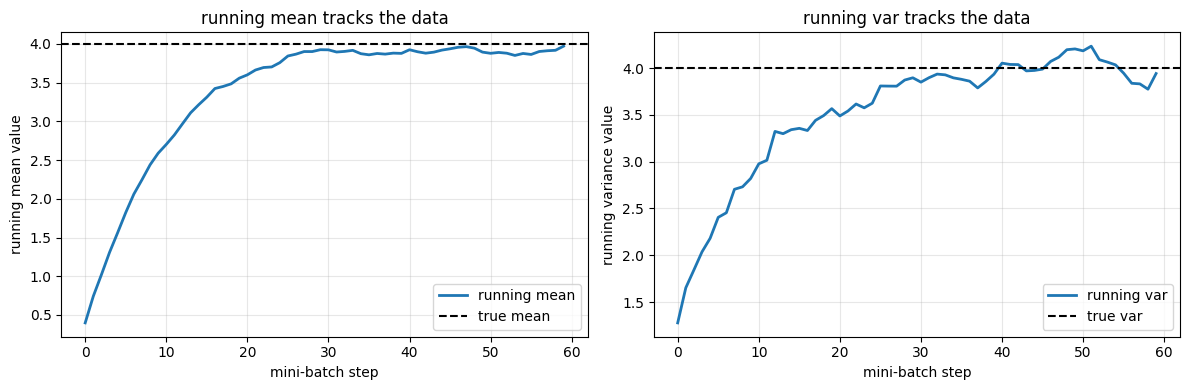

after 60 batches: running mean=3.97 (true 4.0), running var=3.94 (true 4.0)


In [8]:
# train vs eval: feed batches, watch running stats converge to the true data stats
true_mean, true_std = 4.0, 2.0
bn = BatchNorm(1, momentum=0.1)
hist_mean, hist_var = [], []
for _ in range(60):
    batch = np.random.randn(64, 1) * true_std + true_mean
    bn.forward(batch, training=True)
    hist_mean.append(bn.run_mean[0]); hist_var.append(bn.run_var[0])

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(hist_mean, lw=2, label="running mean"); ax[0].axhline(true_mean, ls="--", color="k", label="true mean")
ax[0].set_title("running mean tracks the data"); ax[0].legend(); ax[0].grid(alpha=0.3)
ax[1].plot(hist_var, lw=2, label="running var"); ax[1].axhline(true_std**2, ls="--", color="k", label="true var")
ax[1].set_title("running var tracks the data"); ax[1].legend(); ax[1].grid(alpha=0.3)
ax[0].set_xlabel("mini-batch step"); ax[0].set_ylabel("running mean value")
ax[1].set_xlabel("mini-batch step"); ax[1].set_ylabel("running variance value")
plt.tight_layout(); plt.show()
print(f"after 60 batches: running mean={bn.run_mean[0]:.2f} (true {true_mean}), running var={bn.run_var[0]:.2f} (true {true_std**2})")


**What to notice.** The running statistics (solid) climb from their init (`mean=0, var=1`) toward the true data values (dashed) as an exponential moving average. At **eval** time BatchNorm uses these converged numbers instead of the batch, so a single test example gets normalized by the *population* statistics it never had access to on its own. This is the machinery behind `model.train()` / `model.eval()` — and why a model that looks great in training can silently break at inference if you forget to switch modes (the running stats hadn't converged, or you kept using noisy batch stats on tiny eval batches).

**BatchNorm vs LayerNorm — why transformers chose LN.** BatchNorm couples every example to the others in its batch (they share the mean/var). That's fine for fixed-size image batches, but it's a nightmare for language models: sequences have variable length, batches can be tiny, and you often generate one token at a time — there's no meaningful "batch" to normalize over, and train/eval stats mismatch hurts. **LayerNorm normalizes within each example**, so it's completely independent of batch size and sequence length. That independence is why every transformer uses LayerNorm (or RMSNorm). Same three-term backward math — just reduced over a different axis, and that axis choice changes everything about where the layer is usable.


## 5. Conv2d — local connectivity and weight sharing (via im2col)

**Intuition.** A `Linear` layer connects every input to every output — enormous and blind to spatial structure. A **convolution** instead slides a small kernel across the image: each output pixel looks only at a local patch (**local connectivity**), and the *same* kernel weights are reused at every location (**weight sharing**). That's how a conv learns a reusable "edge detector" or "texture detector" with very few parameters, and why it's translation-equivariant.

**The im2col trick.** Rather than write four nested loops, we turn convolution into a *single matrix multiply* (which we already know how to differentiate!). **im2col** unrolls every sliding patch into a column; stacking them gives a big matrix `cols`. Then `out = cols @ W_flat.T + b` is just... a Linear layer. So:
- **Forward:** `im2col`, then matmul.
- **Backward:** it's a matmul, so `dW = doutᵀ · cols` and `dcols = dout · W_flat`; then **col2im** scatters `dcols` back to image shape (accumulating where patches overlapped — overlap means reuse means *sum*, the same rule yet again).

This is exactly how the first fast GPU convs were implemented. Let's build it and check against `F.conv2d`.


In [9]:
def im2col(x, KH, KW, stride, pad):
    N, C, H, W = x.shape
    xp = np.pad(x, ((0,0),(0,0),(pad,pad),(pad,pad)))
    OH = (H + 2*pad - KH)//stride + 1
    OW = (W + 2*pad - KW)//stride + 1
    cols = np.zeros((N, C, KH, KW, OH, OW))
    for i in range(KH):
        for j in range(KW):
            cols[:, :, i, j, :, :] = xp[:, :, i:i+stride*OH:stride, j:j+stride*OW:stride]
    # -> (N*OH*OW, C*KH*KW): one row per output position, one col per weight
    cols = cols.transpose(0,4,5,1,2,3).reshape(N*OH*OW, -1)
    return cols, (OH, OW)

def col2im(dcols, x_shape, KH, KW, stride, pad, OH, OW):
    N, C, H, W = x_shape
    dxp = np.zeros((N, C, H+2*pad, W+2*pad))
    d = dcols.reshape(N, OH, OW, C, KH, KW).transpose(0,3,4,5,1,2)
    for i in range(KH):
        for j in range(KW):
            dxp[:, :, i:i+stride*OH:stride, j:j+stride*OW:stride] += d[:, :, i, j, :, :]  # overlap -> sum
    return dxp[:, :, pad:pad+H, pad:pad+W] if pad > 0 else dxp

class Conv2d:
    def __init__(self, C_in, C_out, K, stride=1, pad=0):
        self.W = np.random.randn(C_out, C_in, K, K) * np.sqrt(2.0/(C_in*K*K))
        self.b = np.zeros(C_out)
        self.K, self.stride, self.pad = K, stride, pad
    def forward(self, x):
        self.x_shape = x.shape
        C_out = self.W.shape[0]
        self.cols, (OH, OW) = im2col(x, self.K, self.K, self.stride, self.pad)
        self.OH, self.OW = OH, OW
        out = self.cols @ self.W.reshape(C_out, -1).T + self.b   # (N*OH*OW, C_out)
        N = x.shape[0]
        return out.reshape(N, OH, OW, C_out).transpose(0,3,1,2)   # -> (N, C_out, OH, OW)
    def backward(self, dout):
        N, C_out, OH, OW = dout.shape
        dout2 = dout.transpose(0,2,3,1).reshape(N*OH*OW, C_out)   # match forward's row order
        self.dW = (dout2.T @ self.cols).reshape(self.W.shape)     # like Linear's X^T Ȳ
        self.db = dout2.sum(axis=0)
        dcols = dout2 @ self.W.reshape(C_out, -1)                 # like Ȳ W^T
        return col2im(dcols, self.x_shape, self.K, self.K, self.stride, self.pad, OH, OW)

# --- verify vs PyTorch ---
x = np.random.randn(2, 3, 10, 10);
conv = Conv2d(3, 4, K=3, stride=1, pad=1)
y = conv.forward(x); g = np.random.randn(*y.shape)
dx = conv.backward(g)

xt, Wt, bt = as_t(x), as_t(conv.W), as_t(conv.b)
(F.conv2d(xt, Wt, bt, stride=1, padding=1) * torch.tensor(g)).sum().backward()
print("Conv2d:")
compare("forward", y, F.conv2d(xt.detach(), Wt.detach(), bt.detach(), stride=1, padding=1))
compare("dx", dx, xt.grad); compare("dW", conv.dW, Wt.grad); compare("db", conv.db, bt.grad)


Conv2d:
    forward    max|ours - torch| = 8.88e-16   OK ✓
    dx         max|ours - torch| = 8.88e-16   OK ✓
    dW         max|ours - torch| = 1.78e-14   OK ✓
    db         max|ours - torch| = 2.13e-14   OK ✓


2.1316282072803006e-14

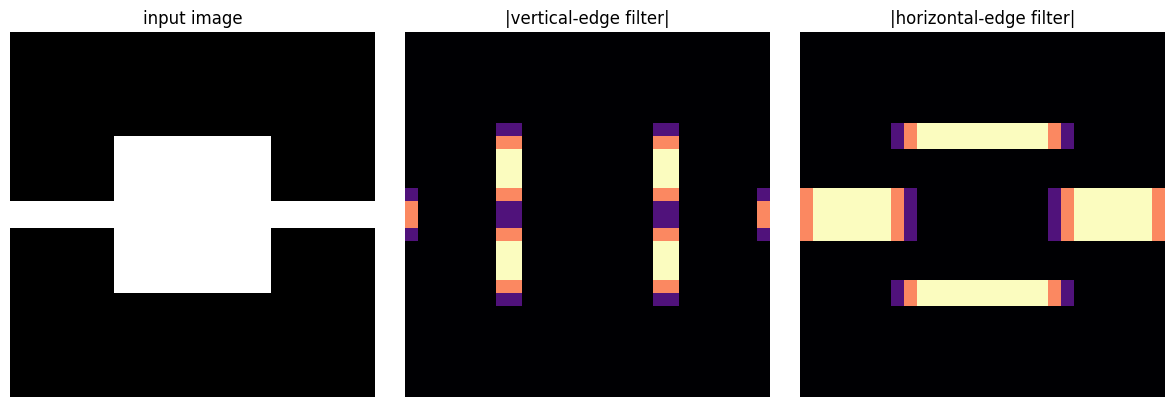

In [10]:
# what a conv actually does: run a hand-set edge kernel over a synthetic image
img = np.zeros((1, 1, 28, 28))
img[0, 0, 8:20, 8:20] = 1.0          # a white square on black
img[0, 0, 13:15, :] = 1.0            # plus a horizontal bar

sobel_x = np.array([[-1,0,1],[-2,0,2],[-1,0,1]], dtype=float)   # vertical-edge detector
sobel_y = sobel_x.T                                             # horizontal-edge detector
edge = Conv2d(1, 2, K=3, stride=1, pad=1)
edge.W = np.stack([sobel_x, sobel_y])[:, None, :, :]           # (2,1,3,3)
edge.b = np.zeros(2)
feats = edge.forward(img)

fig, ax = plt.subplots(1, 3, figsize=(12, 4))
ax[0].imshow(img[0,0], cmap="gray");            ax[0].set_title("input image")
ax[1].imshow(np.abs(feats[0,0]), cmap="magma"); ax[1].set_title("|vertical-edge filter|")
ax[2].imshow(np.abs(feats[0,1]), cmap="magma"); ax[2].set_title("|horizontal-edge filter|")
for a in ax: a.axis("off")
plt.tight_layout(); plt.show()


**What to notice.** The same 3×3 kernel, slid across the whole image (weight sharing), lights up exactly where its kind of edge occurs: the vertical-edge filter fires on the left/right sides of the square, the horizontal-edge filter fires on the top/bottom and along the bar. That's *one* filter with 9 weights detecting a feature *everywhere* — the parameter efficiency and translation-equivariance that make convolutions work. And our from-scratch `forward` matched `F.conv2d` to ~1e-14 while the hand-derived `backward` matched autograd on `dx`, `dW`, `db` — the im2col-makes-it-a-matmul trick, verified.


## 6. What you built

You hand-derived and verified the backward pass of every workhorse layer:

| Layer | Key backward idea | Reduction axis |
|---|---|---|
| **Linear** | matmul chain rule; bias grad sums over batch | — |
| **ReLU / GELU** | elementwise gradient *multiplier* (mask vs smooth curve) | — |
| **LayerNorm** | three routes (direct, mean, var); subtract mean & xhat-correlated part | features |
| **BatchNorm** | same three routes, plus train/eval running stats | batch |
| **Conv2d** | im2col ⇒ it's a matmul; col2im sums overlapping patches | — |

Two ideas recurred everywhere: **reuse ⇒ sum** (bias over the batch, overlapping conv patches, normalization stats), and **every backward is a small, checkable object** you can verify against finite differences or a framework. You never again have to *trust* a layer's gradient — you can derive it and prove it.

## 7. Exercises
1. **RMSNorm.** Implement RMSNorm (LayerNorm without mean-subtraction: divide by $\sqrt{\text{mean}(x^2)+\varepsilon}$, no $\beta$). Derive and verify its backward. It's what LLaMA/most modern LLMs actually use — why might dropping the mean help?
2. **Dropout.** Implement inverted dropout (forward + backward), and explain why it scales by $1/(1-p)$ at train time so eval needs no change.
3. **Conv stride/padding.** Re-run the Conv2d check with `stride=2, pad=0` and a non-square input. Does im2col/col2im still match PyTorch?
4. **Dead ReLU.** Construct an input + weights where a ReLU unit's gradient is 0 for the whole batch. How would GELU or LeakyReLU rescue it?
5. **BatchNorm at batch size 1.** Run BatchNorm forward in training mode with `N=1`. What happens to the variance, and hence the output? (This is *the* argument for LayerNorm.)
6. **Fold the norm backward by hand.** For a `(2,3)` input, expand the LayerNorm `dx` derivation term-by-term without the compact formula, and confirm it equals the compact version.

## 8. Interview / residency framing
- *"Derive the BatchNorm backward pass."* → three routes through $\hat x$, $\mu$, $\sigma^2$; know the compact 3-term form and that it reduces over the batch axis.
- *"BatchNorm vs LayerNorm — when and why?"* → BN normalizes per-feature over the batch (great for CNNs, couples examples, needs running stats + train/eval modes); LN normalizes per-example over features (batch-independent → transformers, variable-length sequences).
- *"Why does GELU help over ReLU?"* → smooth, nonzero gradient for small negatives (no dead units), richer gradient signal near 0.
- *"How is a convolution computed efficiently?"* → im2col unrolls patches so conv becomes a matmul (fast BLAS/GPU); backward is the matmul backward + col2im, where overlapping patches sum.
- *"What's the running mean/variance for?"* → inference-time normalization when there's no batch; the source of the `.eval()` switch and a classic bug.

---
**Next:** *Tier 0 · Notebook 4 — Optimizers from scratch* (SGD → Momentum → Nesterov → RMSProp → Adam → AdamW, and modern ones), each visualized as a trajectory descending a loss surface.


## 📚 References & papers

This notebook reproduces / builds on:

- **Batch Normalization** — Ioffe & Szegedy (2015), arXiv:1502.03167.
- **Layer Normalization** — Ba, Kiros & Hinton (2016), arXiv:1607.06450.
- **Gaussian Error Linear Units (GELUs)** — Hendrycks & Gimpel (2016), arXiv:1606.08415.
- **Gradient-Based Learning Applied to Document Recognition** — LeCun et al. (1998). Convolutions / im2col lineage.